<a href="https://colab.research.google.com/github/Aaguilar123/Macro-Liquidity-Asset-Leaderboard-Forecast/blob/Aaguilar123-patch-1/shared_eda/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Exploration, Preparation, and Feature Engineering for Liquidity Analysis

##Data Preparation and Cleaning

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)

# LOAD & MERGE
df_volume = pd.read_csv('market_volume.csv', index_col='Date', parse_dates=True)
df_macro = pd.read_csv('macro_indicators.csv', index_col='Date', parse_dates=True)

print("Missing Values Check, Handled in Data_pull")
print("Volume Data Missing:\n", df_volume.isnull().sum())
print("\nMacro Data Missing:\n", df_macro.isnull().sum())

# Convert raw CPI index into Month-over-Month (MoM) Inflation Rate (%)
df_macro['CPI_Inflation'] = df_macro['CPI_Inflation'].pct_change(1, fill_method=None) * 100

df_volume.index.name = 'Date'
df_macro.index.name = 'Date'
df_master = df_volume.join(df_macro, how='left').ffill().dropna()

print(f"\nTotal Trading Days after cleaning: {len(df_master)}")

Missing Values Check, Handled in Data_pull
Volume Data Missing:
 BTC-USD    0
GLD        1
QQQ        1
UUP        1
XLP        1
dtype: int64

Macro Data Missing:
 Fed_Rate             0
CPI_Inflation        1
Unemployment_Rate    1
dtype: int64

Total Trading Days after cleaning: 4091


##Feature Engineering and Descriptive Analysis

In [74]:
# Volume Share & Momentum
print("\n>>> Calculating Liquidity Concentration (Volume Share)...")

vol_cols = ['QQQ', 'XLP', 'GLD', 'BTC-USD', 'UUP']

df_master['Total_Volume'] = df_master[vol_cols].sum(axis=1)
for col in vol_cols:
    share_name = f"{col}_Vol_Share"
    df_master[share_name] = (df_master[col] / df_master['Total_Volume']) * 100

share_columns = [c for c in df_master.columns if '_Vol_Share' in c]

print("\n>>> Summary Statistics for Volume Share:")
print(df_master[share_columns].describe().round(2))


>>> Calculating Liquidity Concentration (Volume Share)...

>>> Summary Statistics for Volume Share:
       QQQ_Vol_Share  XLP_Vol_Share  GLD_Vol_Share  BTC-USD_Vol_Share  \
count        4091.00        4091.00        4091.00            4091.00   
mean           41.89           3.80           8.28              45.75   
std            18.51           3.71           8.77              27.09   
min             5.73           0.16           0.54               0.16   
25%            27.38           1.37           2.70              25.84   
50%            40.09           2.16           4.63              52.47   
75%            55.21           5.19           9.78              67.22   
max            88.12          23.67          52.17              92.78   

       UUP_Vol_Share  
count        4091.00  
mean            0.28  
std             0.52  
min             0.01  
25%             0.04  
50%             0.09  
75%             0.27  
max             7.89  


In [75]:
# Calculate Day-over-Day (DoD) Momentum/Growth of that Share
for col in share_columns:
    growth_name = col.replace('_Vol_Share', '_DoD_Growth')
    df_master[growth_name] = df_master[col].pct_change(1, fill_method=None) * 100

df_master.dropna(inplace=True)

###Merged Dataset

In [76]:
df_master.to_csv('final_engineered_data.csv')
print("final_engineered_data.csv complete")
print(df_master.head())

final_engineered_data.csv complete
             BTC-USD           GLD           QQQ           UUP           XLP  \
Date                                                                           
2015-02-02  30612100  1.087726e+09  4.091221e+09  3.805065e+07  5.173709e+08   
2015-02-03  40783700  9.993767e+08  2.911555e+09  8.691396e+07  2.283413e+08   
2015-02-04  26594300  6.549150e+08  3.223348e+09  2.413930e+07  2.874274e+08   
2015-02-05  22516400  8.379030e+08  2.252417e+09  1.908974e+07  2.954082e+08   
2015-02-06  24435300  1.566867e+09  3.240610e+09  5.991427e+07  2.294660e+08   

            Fed_Rate  CPI_Inflation  Unemployment_Rate  Total_Volume  \
Date                                                                   
2015-02-02      0.11       0.253464                5.5  5.764981e+09   
2015-02-03      0.11       0.253464                5.5  4.266970e+09   
2015-02-04      0.11       0.253464                5.5  4.216424e+09   
2015-02-05      0.11       0.253464         

##Exploratory Data Analysis

###Distribution and Outlier Analysis


Distribution Charts:


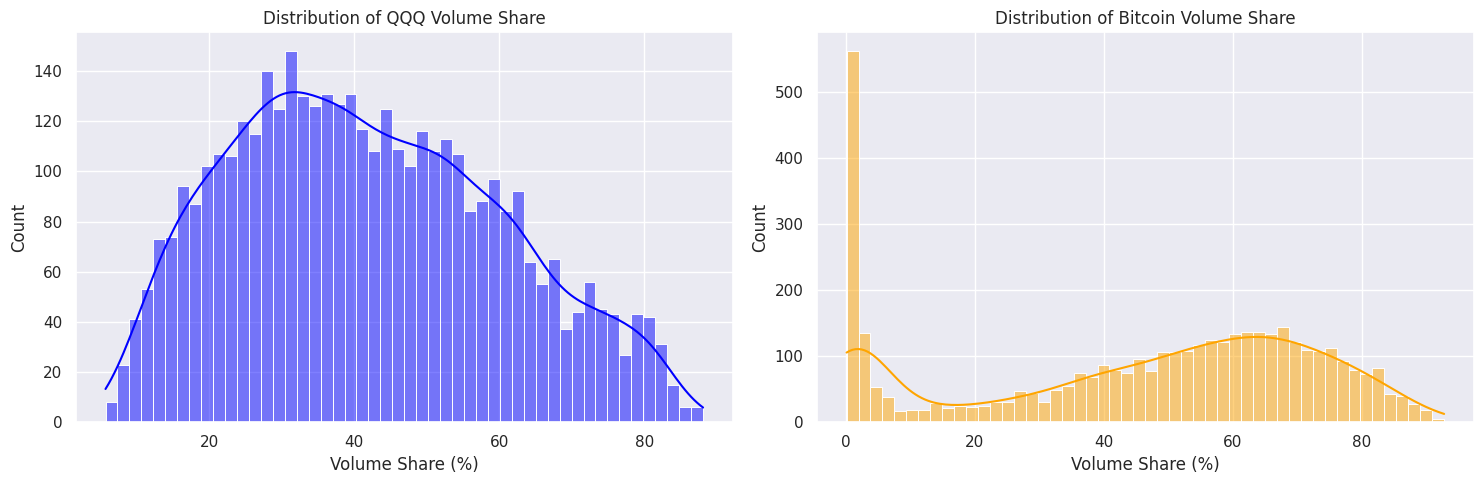


Outlier Boxplots:


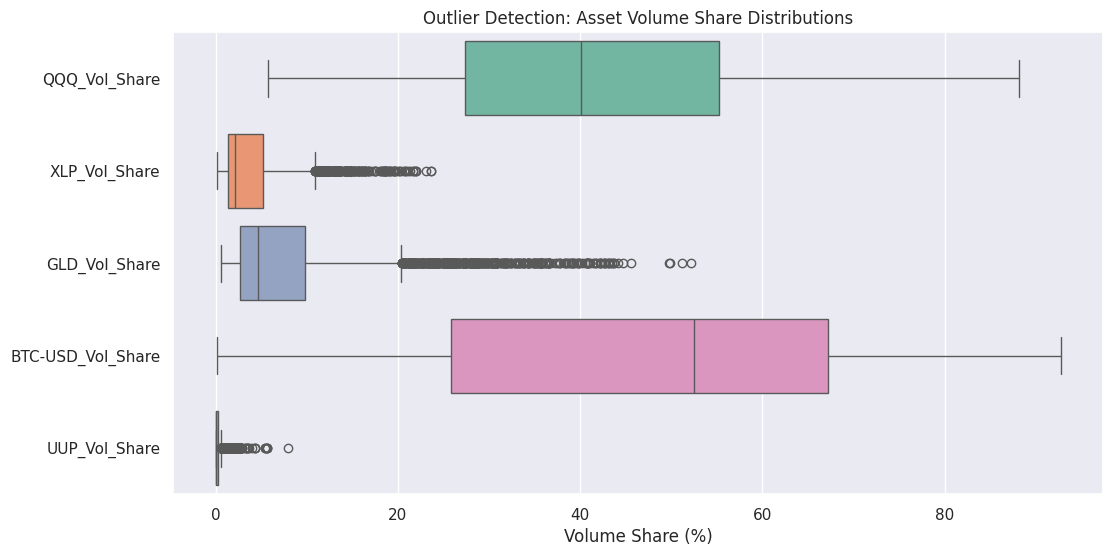

In [77]:
print("\nDistribution Charts:")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_master['QQQ_Vol_Share'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of QQQ Volume Share')
axes[0].set_xlabel('Volume Share (%)')

sns.histplot(df_master['BTC-USD_Vol_Share'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Bitcoin Volume Share')
axes[1].set_xlabel('Volume Share (%)')

plt.tight_layout()
plt.show()

print("\nOutlier Boxplots:")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_master[share_columns], orient="h", palette="Set2")
plt.title('Outlier Detection: Asset Volume Share Distributions')
plt.xlabel('Volume Share (%)')
plt.show()


###Correlation Analysis

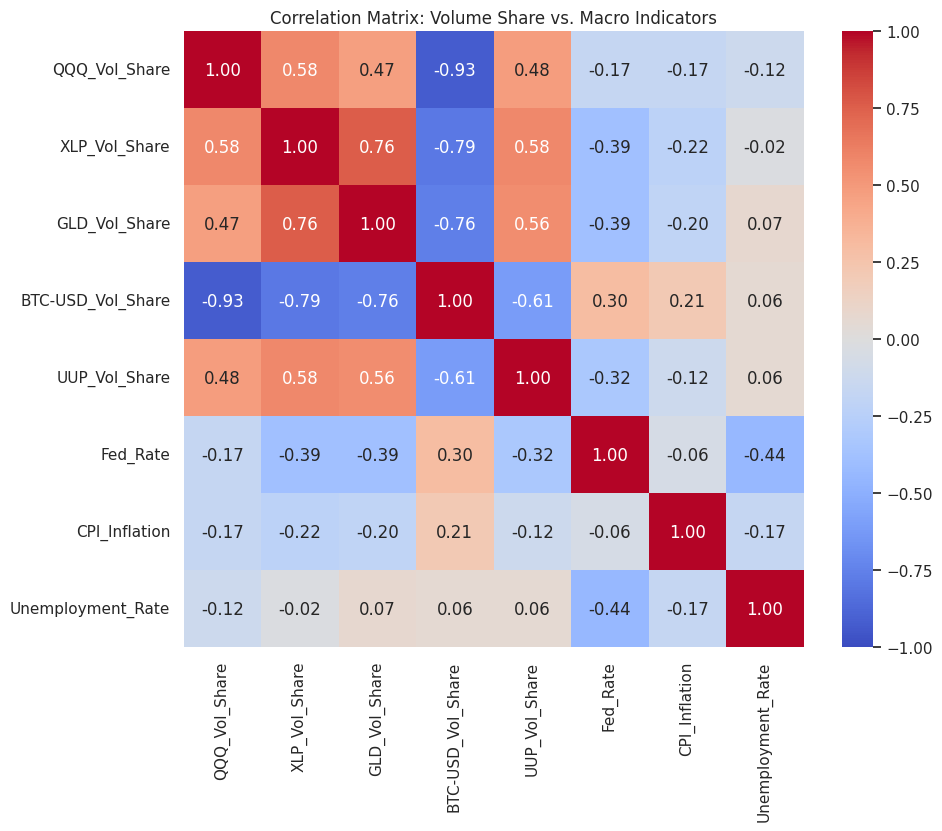

In [78]:
features_to_correlate = share_columns + ['Fed_Rate', 'CPI_Inflation', 'Unemployment_Rate']

corr_matrix = df_master[features_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix: Volume Share vs. Macro Indicators')
plt.show()

##Liquidity Momentum Dynamics and Cross-Asset Ranking

In [79]:
monthly_data = df_master[share_columns].resample('ME').mean()
monthly_momentum = monthly_data.pct_change(1, fill_method=None) * 100
monthly_momentum = monthly_momentum.dropna()

monthly_ranks = monthly_momentum.rank(axis=1, ascending=False)
monthly_ranks.columns = [c.replace('_Vol_Share', '_Momentum_Rank') for c in monthly_ranks.columns]
monthly_ranks['Momentum_Winner'] = monthly_momentum.idxmax(axis=1).str.replace('_Vol_Share', '')

print("\nRecent Momentum Winners (Highest Relative Growth):")
print(monthly_ranks[['Momentum_Winner']].tail())


Recent Momentum Winners (Highest Relative Growth):
           Momentum_Winner
Date                      
2025-12-31             GLD
2026-01-31             GLD
2026-02-28             XLP
2026-03-31             UUP
2026-04-30             UUP


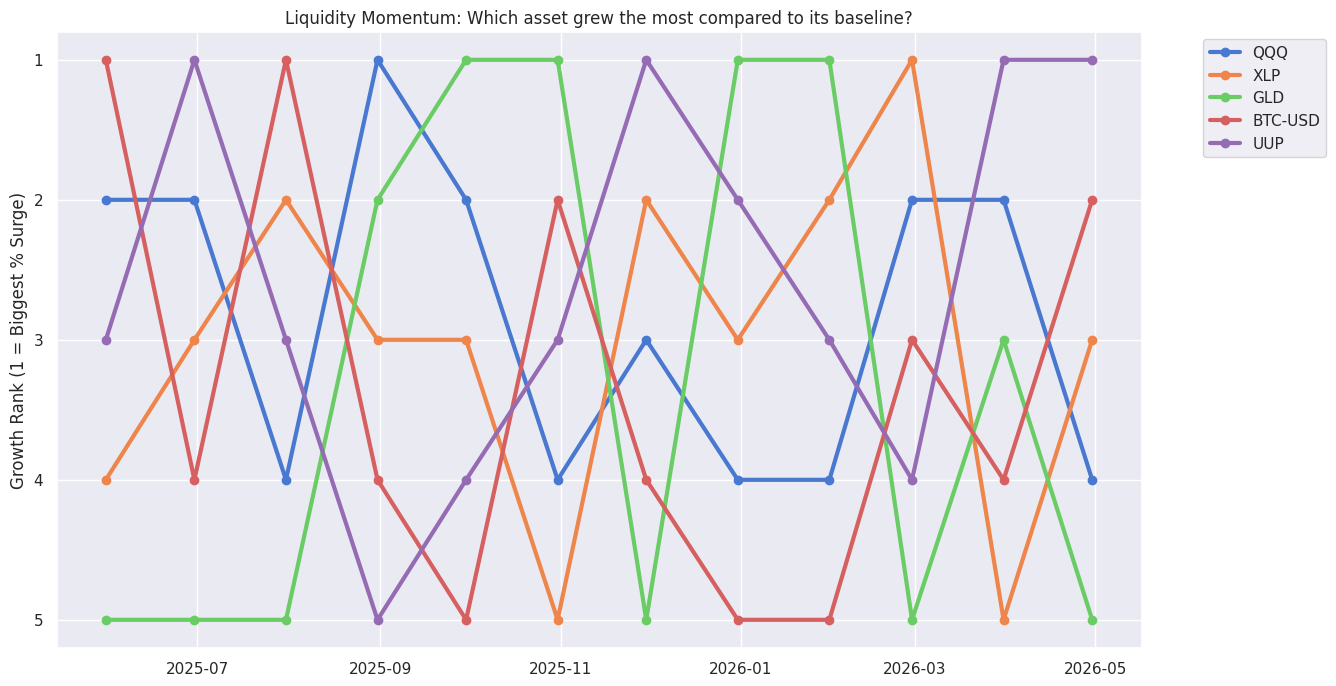

In [80]:
plt.figure(figsize=(14, 8))

recent_ranks = monthly_ranks.iloc[-12:].copy()
for col in [c for c in recent_ranks.columns if '_Rank' in c]:
    plt.plot(recent_ranks.index, recent_ranks[col], marker='o', linewidth=3, label=col.replace('_Momentum_Rank',''))

plt.gca().invert_yaxis()
plt.yticks([1, 2, 3, 4, 5])
plt.title('Liquidity Momentum: Which asset grew the most compared to its baseline?')
plt.ylabel('Growth Rank (1 = Biggest % Surge)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()